# Transect and regional density biases: CESM3 / MOM6 experiment comparison

Regional potential density ($\sigma_2$) transects and basin zonal averages
for a set of coupled and forced experiments. This notebook ports the
regional $\sigma_2$ diagnostics from `biases.ipynb` (Section 10) into a
standalone notebook and adds Pacific- and Indian-Ocean zonal averages. The
shared `Experiment` class lives in `experiment.py`.

**Experiments compared**

| name | mode | data folder |
|------|------|-------------|
| `CTRL` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0_uANN_1.0` | coupled | `data/coupled_55years` |
| `forced_CTRL` | forced | `data/forced_55years` |
| `forced_bANN_1.0` | forced | `data/forced_55years` |
| `forced_bANN_1.0_uANN_1.0` | forced | `data/forced_55years` |

**Kernel:** `env-from-npl-2024a` (Python 3.11.6).

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import cftime
import gsw

from experiment import Experiment

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 18})

# Repo-root-relative paths (this notebook lives in <repo>/notebooks)
REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
YAML_DIR = os.path.join(REPO, 'yamls')
COUPLED_DIR = os.path.join(REPO, 'data', 'coupled_55years')
FORCED_DIR = os.path.join(REPO, 'data', 'forced_55years')
FIG_DIR = os.path.join(REPO, 'figures', 'coupled_55years')

print('REPO       =', REPO)
print('YAML_DIR   =', YAML_DIR)
print('COUPLED_DIR=', COUPLED_DIR)
print('FORCED_DIR =', FORCED_DIR)

REPO       = /glade/u/home/pavelp/m2lines-CESM3-diagnostics
YAML_DIR   = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/yamls
COUPLED_DIR= /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/coupled_55years
FORCED_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/forced_55years


## Initialize experiments (read-only)

Each experiment is defined by its `name`, the diagnostics YAML config, and the
folder holding its postprocessed NetCDF files. Initialization is read-only: it
only reads config + (best-effort) grid, and never triggers heavy computation.

In [2]:
# (name, folder) for each experiment. YAML config is yamls/<name>.yaml
experiment_defs = [
    ('CTRL',                        COUPLED_DIR),
    ('coupled_bANN_1.0',            COUPLED_DIR),
    ('coupled_bANN_1.0_uANN_1.0',   COUPLED_DIR),
    ('forced_CTRL',                 FORCED_DIR),
    ('forced_bANN_1.0',             FORCED_DIR),
    ('forced_bANN_1.0_uANN_1.0',    FORCED_DIR),
]

exps = {}
for name, folder in experiment_defs:
    yaml_path = os.path.join(YAML_DIR, f'{name}.yaml')
    exps[name] = Experiment(yaml_path, folder=folder, name=name,
                            load_grid=True, verbose=True)

exp_names = list(exps.keys())
coupled_names = ['coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0', 'CTRL' ]
forced_names = ['forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0', 'forced_CTRL']

print('\nInitialized:', exp_names)

# Column order for the 2x3 panels: GM first, then the two ANN experiments.
coupled_row = ['CTRL', 'coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0']
forced_row = ['forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']

[CTRL] casename=CTRL, rundir=/glade/derecho/scratch/jiarongw/CTRL/run


ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/pavelp/conda-envs/env-from-npl-2024a/share/proj failed


MOM6 grid successfully loaded... 

[coupled_bANN_1.0] casename=coupled_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0/run
MOM6 grid successfully loaded... 

[coupled_bANN_1.0_uANN_1.0] casename=coupled_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 

[forced_CTRL] casename=forced_CTRL, rundir=/glade/derecho/scratch/pavelp/forced_CTRL/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0] casename=forced_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0_uANN_1.0] casename=forced_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 


Initialized: ['CTRL', 'coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0', 'forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']


In [3]:
# Short legend labels (regime is shown in the panel title, so it is omitted here)
LABELS = {
    'CTRL':                       'GM',
    'coupled_bANN_1.0':           'bANN',
    'coupled_bANN_1.0_uANN_1.0':  'bANN_uANN',
    'forced_CTRL':                'GM',
    'forced_bANN_1.0':            'bANN',
    'forced_bANN_1.0_uANN_1.0':   'bANN_uANN',
}

## Shared machinery (zonal average, depth axis, $\sigma_2$)

Helpers ported from `biases.ipynb`: the tripolar-safe latitude binning
(`zonal_ave`), the piecewise-stretched depth axis, the observational
$\sigma_2$ (WOA-2018 recovered as `model - bias`), and the shared contour
levels.

In [4]:
# --- Zonally-averaged bias / response sections (latitude vs depth) ---
# Reuses the precomputed model - WOA18 bias fields; the zonal average and
# depth-axis styling follow notebooks-development/compare_runs_coupled.ipynb.

def zonal_ave(array, geolat):
    """Bin a field into 1-degree latitude bands using true geolat (tripolar-safe)."""
    bins = array.yh.values
    bins = (bins[:-1] + bins[1:]) / 2
    return array.groupby_bins(geolat, bins=bins).mean()

# Piecewise-linear depth axis: 0-200, 200-1000, 1000-5500 m each get 1/3 of the height
d_edges = [0, 200, 1000, 5500]

def _depth_forward(d):
    d = np.asarray(d, dtype=float)
    return np.where(d <= d_edges[1], (d - d_edges[0]) / (d_edges[1] - d_edges[0]) / 3,
           np.where(d <= d_edges[2], 1 / 3 + (d - d_edges[1]) / (d_edges[2] - d_edges[1]) / 3,
                    2 / 3 + (d - d_edges[2]) / (d_edges[3] - d_edges[2]) / 3))

def _depth_inverse(y):
    y = np.asarray(y, dtype=float)
    return np.where(y <= 1 / 3, d_edges[0] + y * 3 * (d_edges[1] - d_edges[0]),
           np.where(y <= 2 / 3, d_edges[1] + (y - 1 / 3) * 3 * (d_edges[2] - d_edges[1]),
                    d_edges[2] + (y - 2 / 3) * 3 * (d_edges[3] - d_edges[2])))


def obs_sigma2(exp):
    """Observational sigma2 (WOA-2018) recovered from model field minus bias."""
    t = exp.thetao()
    s = exp.so()
    thetao_obs = t.thetao - t.thetao_bias
    so_obs = s.so - s.so_bias
    return gsw.sigma2(so_obs, thetao_obs)


# Contour levels shared with biases.ipynb
DZONAL_LEVELS = np.arange(-0.275, 0.28, 0.05)   # sigma2 bias filled contours
SIGMA2_LEVELS = np.arange(30.0, 37.51, 0.5)      # observed sigma2 isolines

# 1. Regional potential density ($\sigma_2$) bias and response

Regional views of the $\sigma_2$ bias (`model $-$ WOA18`) and response
(`exp $-$ GM`), computed with `gsw.sigma2` (WOA-2018 recovered as
model $-$ bias) and drawn in a 2x3 (coupled / forced) bias+response layout
with a gray land background:

- **Drake Passage** - meridional section at 70W, 70S-55S.
- **Weddell Sea** - meridional section at 42W, 80S-50S.
- **North Atlantic** - zonal average over the Atlantic basin mask, 0-70N.
- **Pacific Ocean** - zonal average over the Pacific basin mask.
- **Indian Ocean** - zonal average over the Indian basin mask.

In [14]:
# --- Section 10: regional sigma2 bias / response reducers + plotter ---
# Reuses obs_sigma2, zonal_ave, the piecewise depth axis and DZONAL_LEVELS.

# Atlantic basin mask (same definition as key_diagnostics.ipynb).
basin_code_xr = exps['CTRL'].basin_code_xr
atl_mask = (basin_code_xr.sel(region='AtlanticOcean') + basin_code_xr.sel(region='Arctic') +
            basin_code_xr.sel(region='MedSea') + basin_code_xr.sel(region='BlackSea') +
            basin_code_xr.sel(region='HudsonBay'))
pac_mask = basin_code_xr.sel(region='PacificOcean')
ind_mask = basin_code_xr.sel(region='IndianOcean')
so_mask = basin_code_xr.sel(region='SouthernOcean')


def lon_section(field3d, exp, lon0, lat_min, lat_max):
    """Meridional section of a (z_l, yh, xh) field at longitude lon0, over
    [lat_min, lat_max]. For each yh the grid column nearest lon0 is selected."""
    geolon, geolat = exp.grd.geolon, exp.grd.geolat
    ydim, xdim = geolon.dims
    dlon = ((geolon - lon0 + 180) % 360) - 180
    dlon = np.abs(dlon).fillna(np.inf)                 # land points -> large distance
    ix = dlon.argmin(dim=xdim)                         # (yh,)
    sec = field3d.isel({xdim: ix})                     # (z_l, yh)
    sec = sec.assign_coords(lat=(ydim, geolat.isel({xdim: ix}).values))
    sec = sec.swap_dims({ydim: 'lat'}).sortby('lat')
    return sec.where((sec.lat >= lat_min) & (sec.lat <= lat_max), drop=True)


def atl_zonal(field3d, exp, lat_min=0.0, lat_max=70.0):
    """Zonal average of a (z_l, yh, xh) field over the Atlantic mask."""
    zm = zonal_ave(field3d.where(atl_mask > 0), exp.grd.geolat)
    lat = np.array([iv.mid for iv in zm['geolat_bins'].values], dtype=float)
    zm = zm.assign_coords(geolat_bins=lat).rename(geolat_bins='lat')
    return zm.sortby('lat').sel(lat=slice(lat_min, lat_max))


def pac_zonal(field3d, exp, lat_min=-40.0, lat_max=70.0):
    # Zonal average of a (z_l, yh, xh) field over the Pacific mask.
    zm = zonal_ave(field3d.where(pac_mask > 0), exp.grd.geolat)
    lat = np.array([iv.mid for iv in zm['geolat_bins'].values], dtype=float)
    zm = zm.assign_coords(geolat_bins=lat).rename(geolat_bins='lat')
    return zm.sortby('lat').sel(lat=slice(lat_min, lat_max))


def ind_zonal(field3d, exp, lat_min=-40.0, lat_max=30.0):
    # Zonal average of a (z_l, yh, xh) field over the Indian mask.
    zm = zonal_ave(field3d.where(ind_mask > 0), exp.grd.geolat)
    lat = np.array([iv.mid for iv in zm['geolat_bins'].values], dtype=float)
    zm = zm.assign_coords(geolat_bins=lat).rename(geolat_bins='lat')
    return zm.sortby('lat').sel(lat=slice(lat_min, lat_max))


def so_zonal(field3d, exp, lat_min=-80.0, lat_max=-30.0):
    # Zonal average of a (z_l, yh, xh) field over the Southern Ocean mask.
    zm = zonal_ave(field3d.where(so_mask > 0), exp.grd.geolat)
    lat = np.array([iv.mid for iv in zm['geolat_bins'].values], dtype=float)
    zm = zm.assign_coords(geolat_bins=lat).rename(geolat_bins='lat')
    return zm.sortby('lat').sel(lat=slice(lat_min, lat_max))


def plot_sigma2_region(reduce_fn, region_title, diff_levels=DZONAL_LEVELS,
                       cmap='RdBu_r', uniform_depth=False,
                       obs_levels=SIGMA2_LEVELS, depth_max=None):
    """2x3 (coupled/forced) sigma2 bias (GM - WOA18) and response (exp - GM)
    reduced to a (z_l, lat) section/average by reduce_fn(field3d, exp).
    Left column overlays observed (WOA18) sigma2 isolines. With uniform_depth
    the vertical axis is linear instead of the piecewise-stretched one; depth_max
    optionally caps the vertical extent."""
    get_bias = lambda e: e.sigma2() - obs_sigma2(e)
    fig, axes = plt.subplots(2, 3, figsize=(22, 12), dpi=150,
                             sharex=True, sharey=True, constrained_layout=True)
    im = None
    for row, (regime, names) in enumerate([('Coupled', coupled_row),
                                           ('Forced', forced_row)]):
        gm_bias = get_bias(exps[names[0]])
        for col, name in enumerate(names):
            ax = axes[row, col]
            bias = get_bias(exps[name])
            bias_sec = reduce_fn(bias, exps[name])          # model - WOA18
            if col == 0:
                field = bias_sec
                title = f'{regime}: {LABELS[name]} ' + r'$-$' + ' WOA18'
            else:
                field = reduce_fn(bias - gm_bias, exps[name])  # exp - GM
                title = f'{regime}: {LABELS[name]} ' + r'$-$' + ' GM'
            rmse = float(np.sqrt((bias_sec ** 2).mean()))    # RMSE always vs WOA18
            im = field.plot.contourf(ax=ax, x='lat', levels=diff_levels, cmap=cmap,
                                     extend='both', add_colorbar=False)
            if col == 0:
                obs_red = reduce_fn(obs_sigma2(exps[name]), exps[name])
                cs = obs_red.plot.contour(ax=ax, x='lat', levels=obs_levels,
                                          colors='k', linewidths=0.6)
                ax.clabel(cs, fmt='%g', fontsize=8)
            ax.set_title(f'{title}\nRMSE={rmse:.3f} kg m$^{{-3}}$')
            if uniform_depth:
                ax.set_ylim(depth_max if depth_max is not None
                            else float(field['z_l'].max()), 0)
            else:
                ax.set_yscale('function', functions=(_depth_forward, _depth_inverse))
                ax.set_ylim(depth_max if depth_max is not None else d_edges[3],
                            d_edges[0])
                ax.set_yticks([0, 100, 200, 500, 1000, 2000, 3000, 4000, 5000, 5500])
                for d in (d_edges[1], d_edges[2]):
                    ax.axhline(d, color='0.5', lw=0.8, ls='--')
            ax.set_xlabel('Latitude' if row == 1 else '')
            ax.set_ylabel('Depth [m]' if col == 0 else '')
            ax.set_facecolor('gray')
    cbar = fig.colorbar(im, ax=axes, label=r'$\sigma_2$ bias [kg m$^{-3}$]',
                        extend='both', ticks=diff_levels, spacing='uniform',
                        shrink=0.85, pad=0.02)
    cbar.ax.set_yticklabels([f'{b:g}' for b in diff_levels])
    fig.suptitle(region_title, fontsize=26)
    plt.show()

## Drake Passage (70$\degree$W)

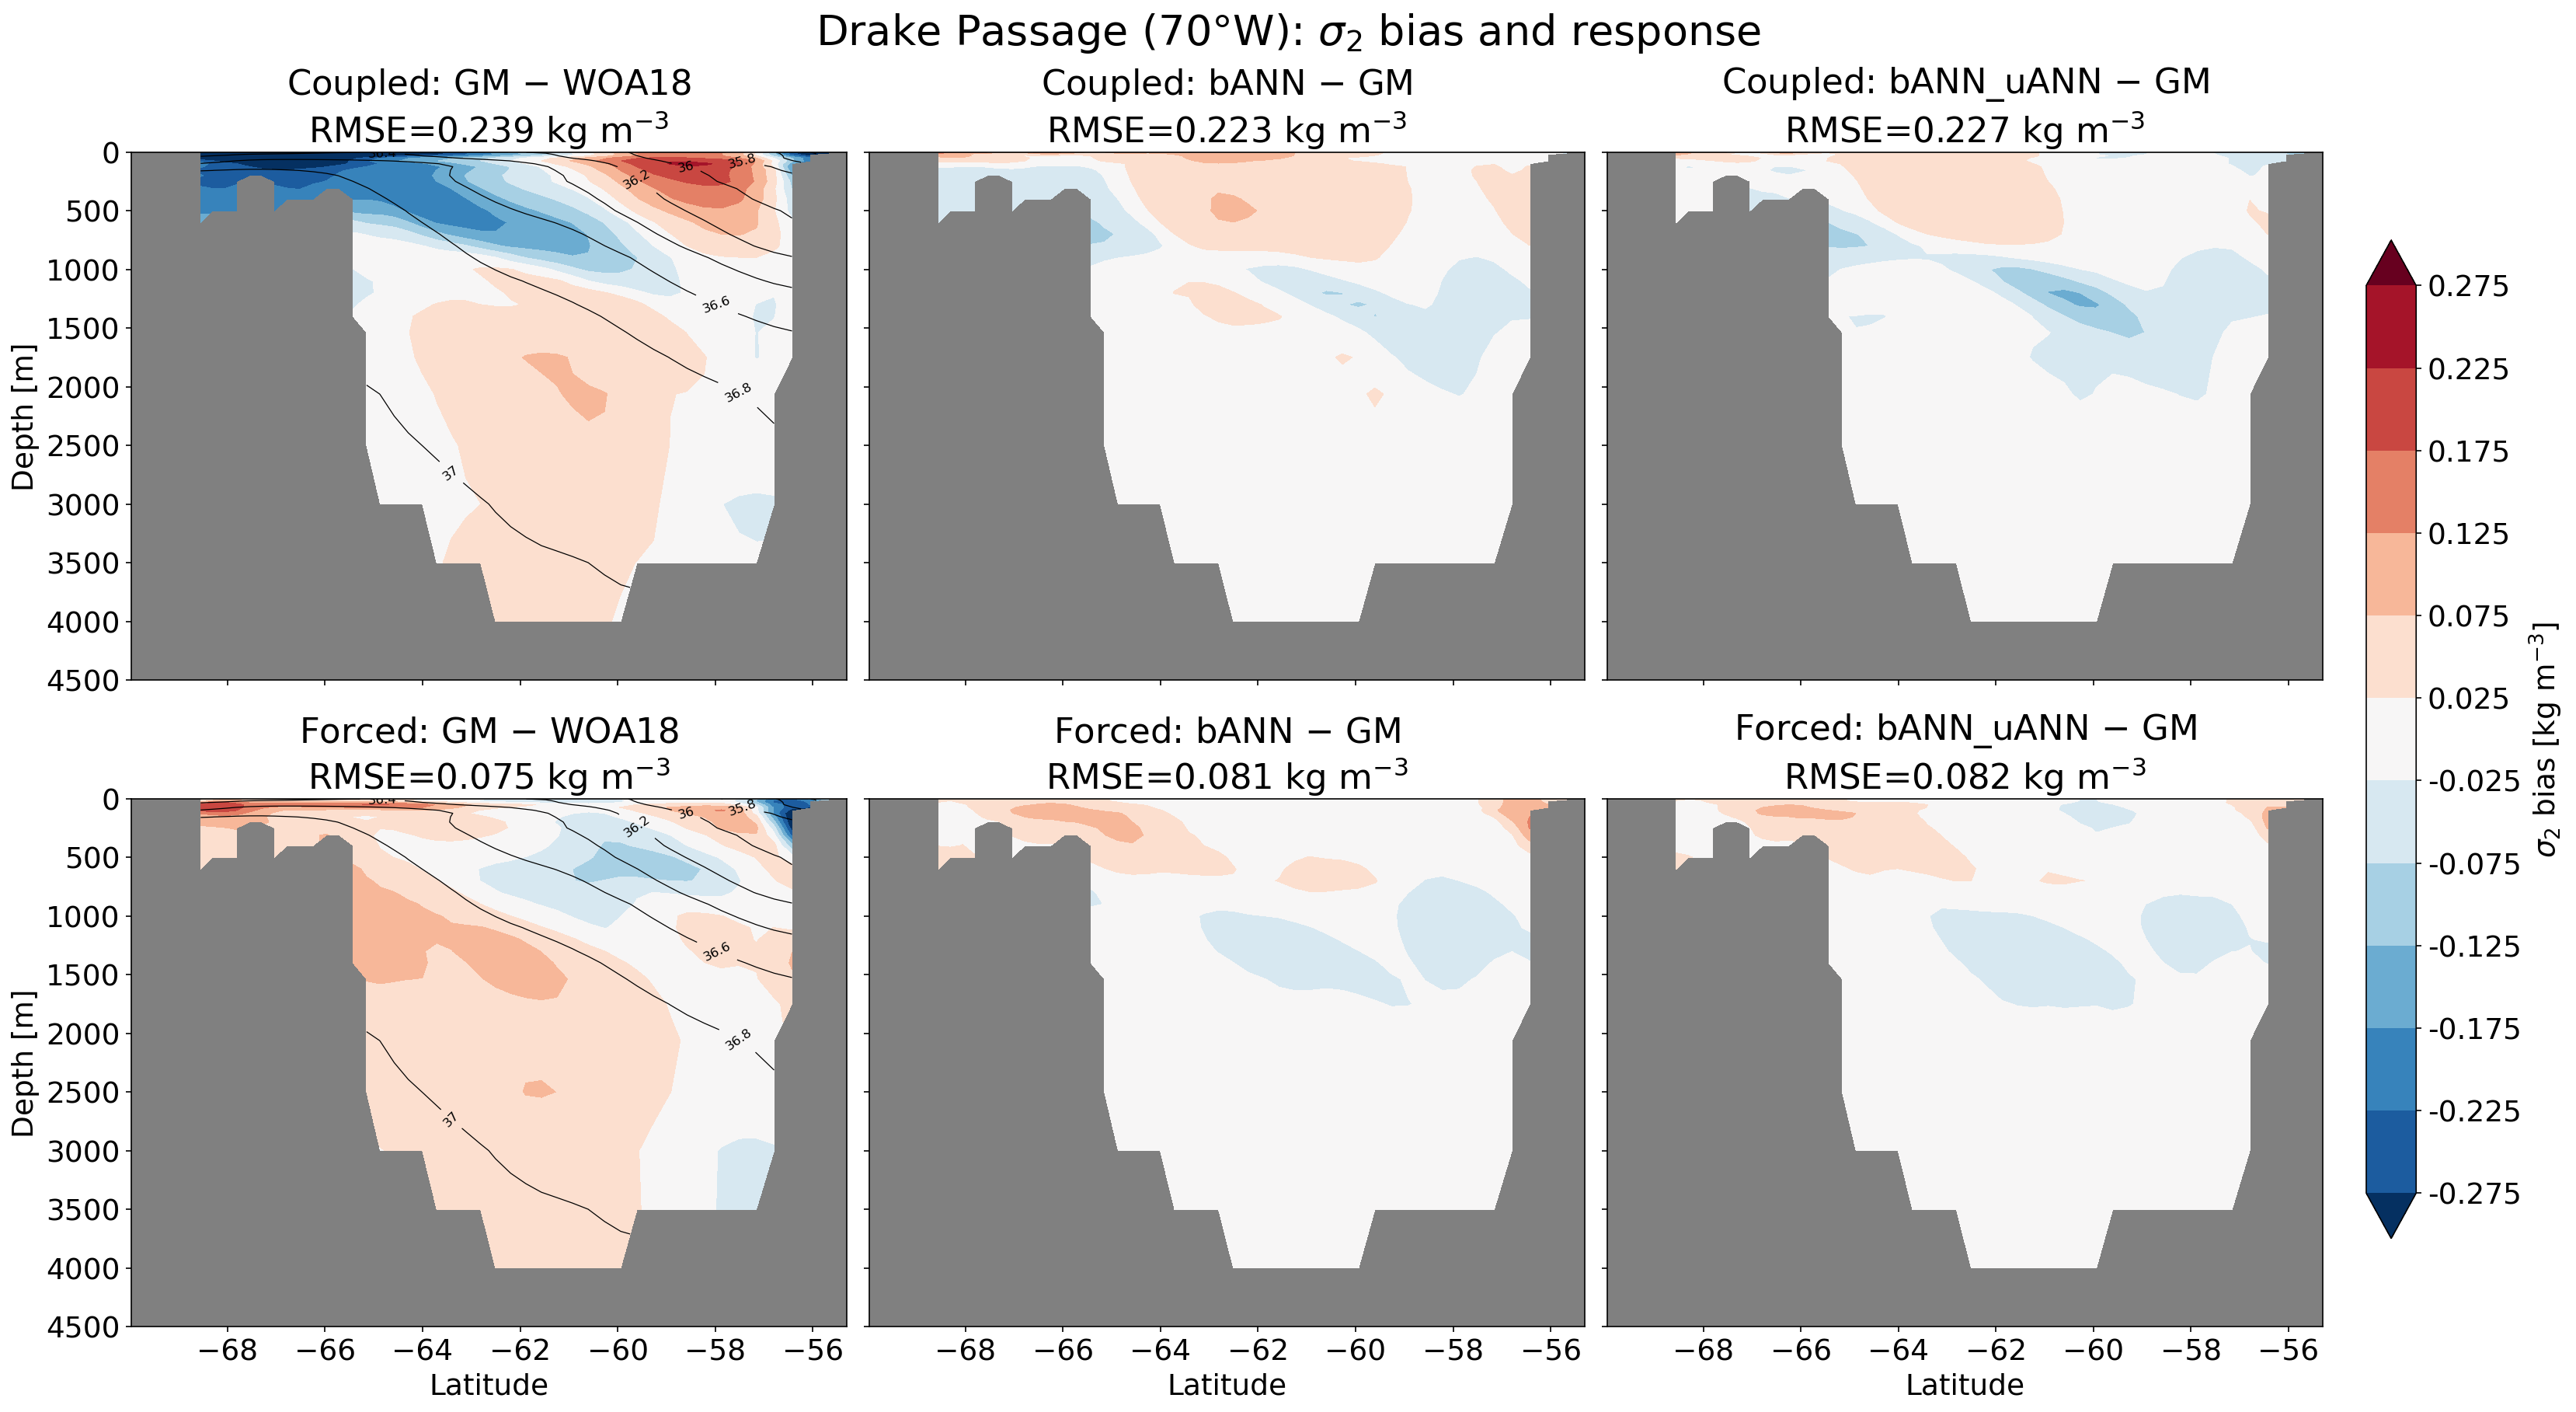

In [6]:
# Drake Passage: meridional section at 70W, 70S-55S
plot_sigma2_region(lambda f, e: lon_section(f, e, -70.0, -70.0, -55.0),
                   r'Drake Passage (70$\degree$W): $\sigma_2$ bias and response',
                   uniform_depth=True, obs_levels=np.arange(30.0, 37.61, 0.2),
                   depth_max=4500.0)

## Weddell Sea (42$\degree$W)

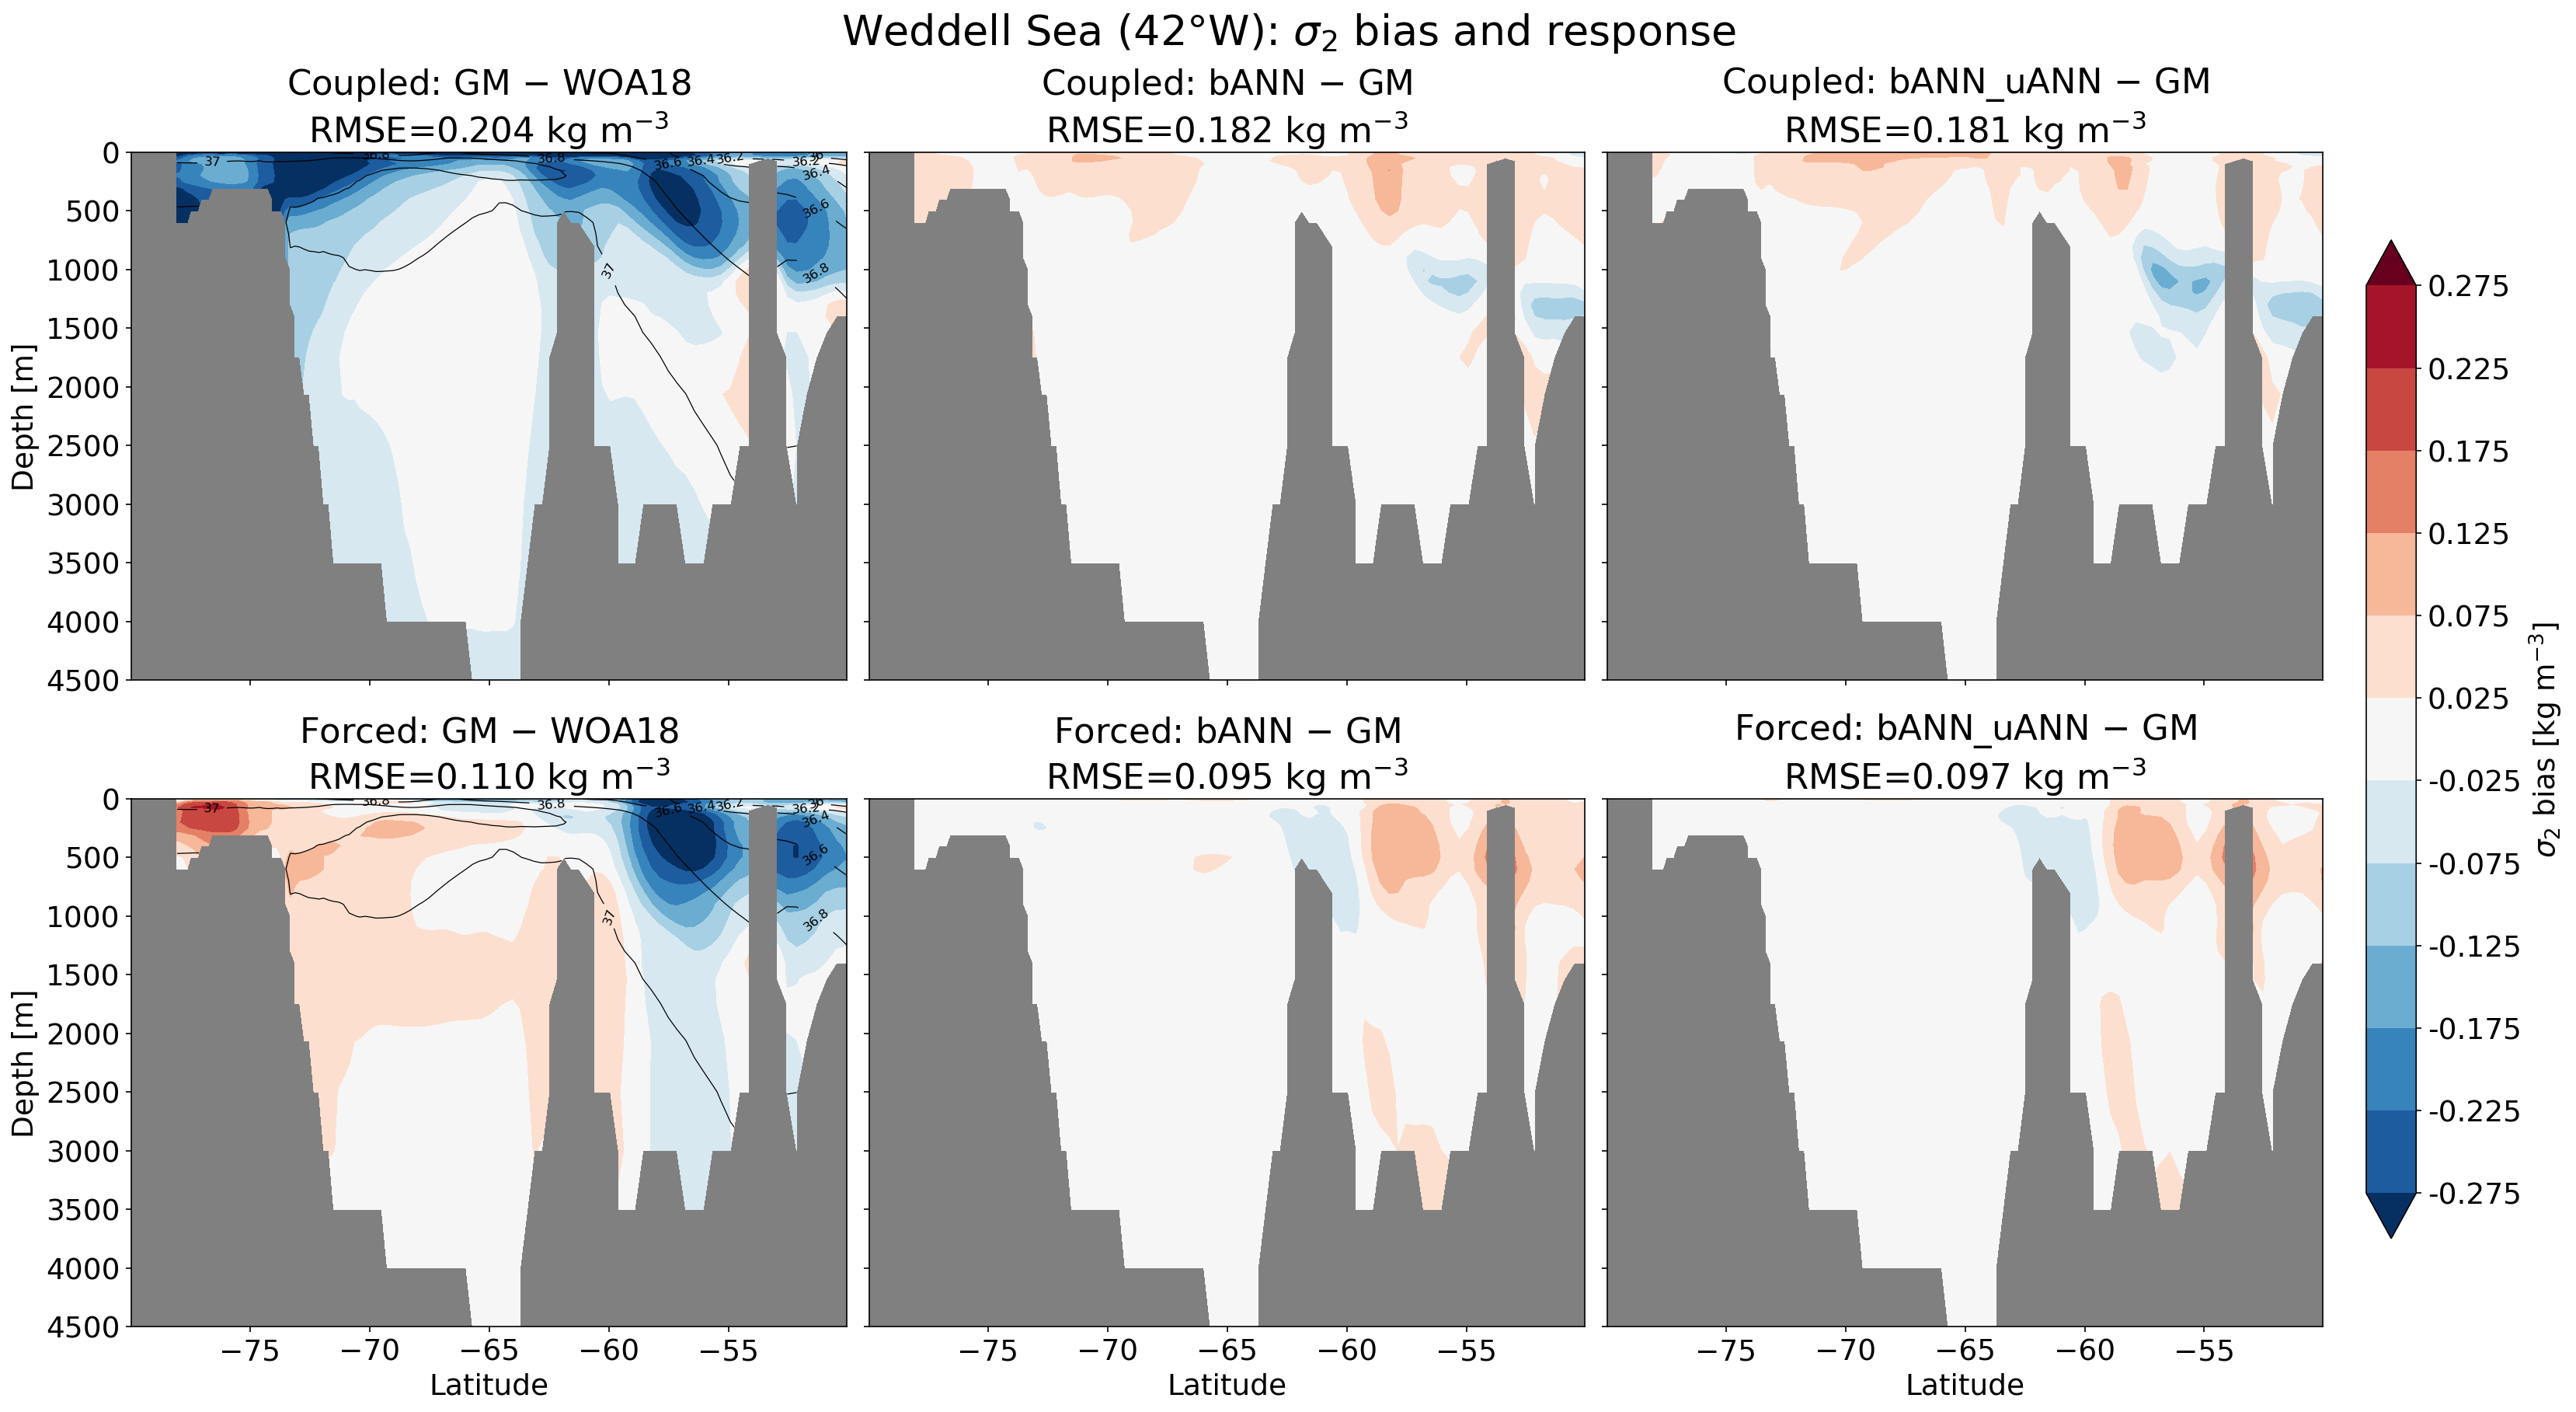

In [7]:
# Weddell Sea: meridional section at 42W, 80S-50S
plot_sigma2_region(lambda f, e: lon_section(f, e, -42.0, -80.0, -50.0),
                   r'Weddell Sea (42$\degree$W): $\sigma_2$ bias and response',
                   uniform_depth=True, obs_levels=np.arange(30.0, 37.61, 0.2),
                   depth_max=4500.0)

## Southern Ocean (zonal average)

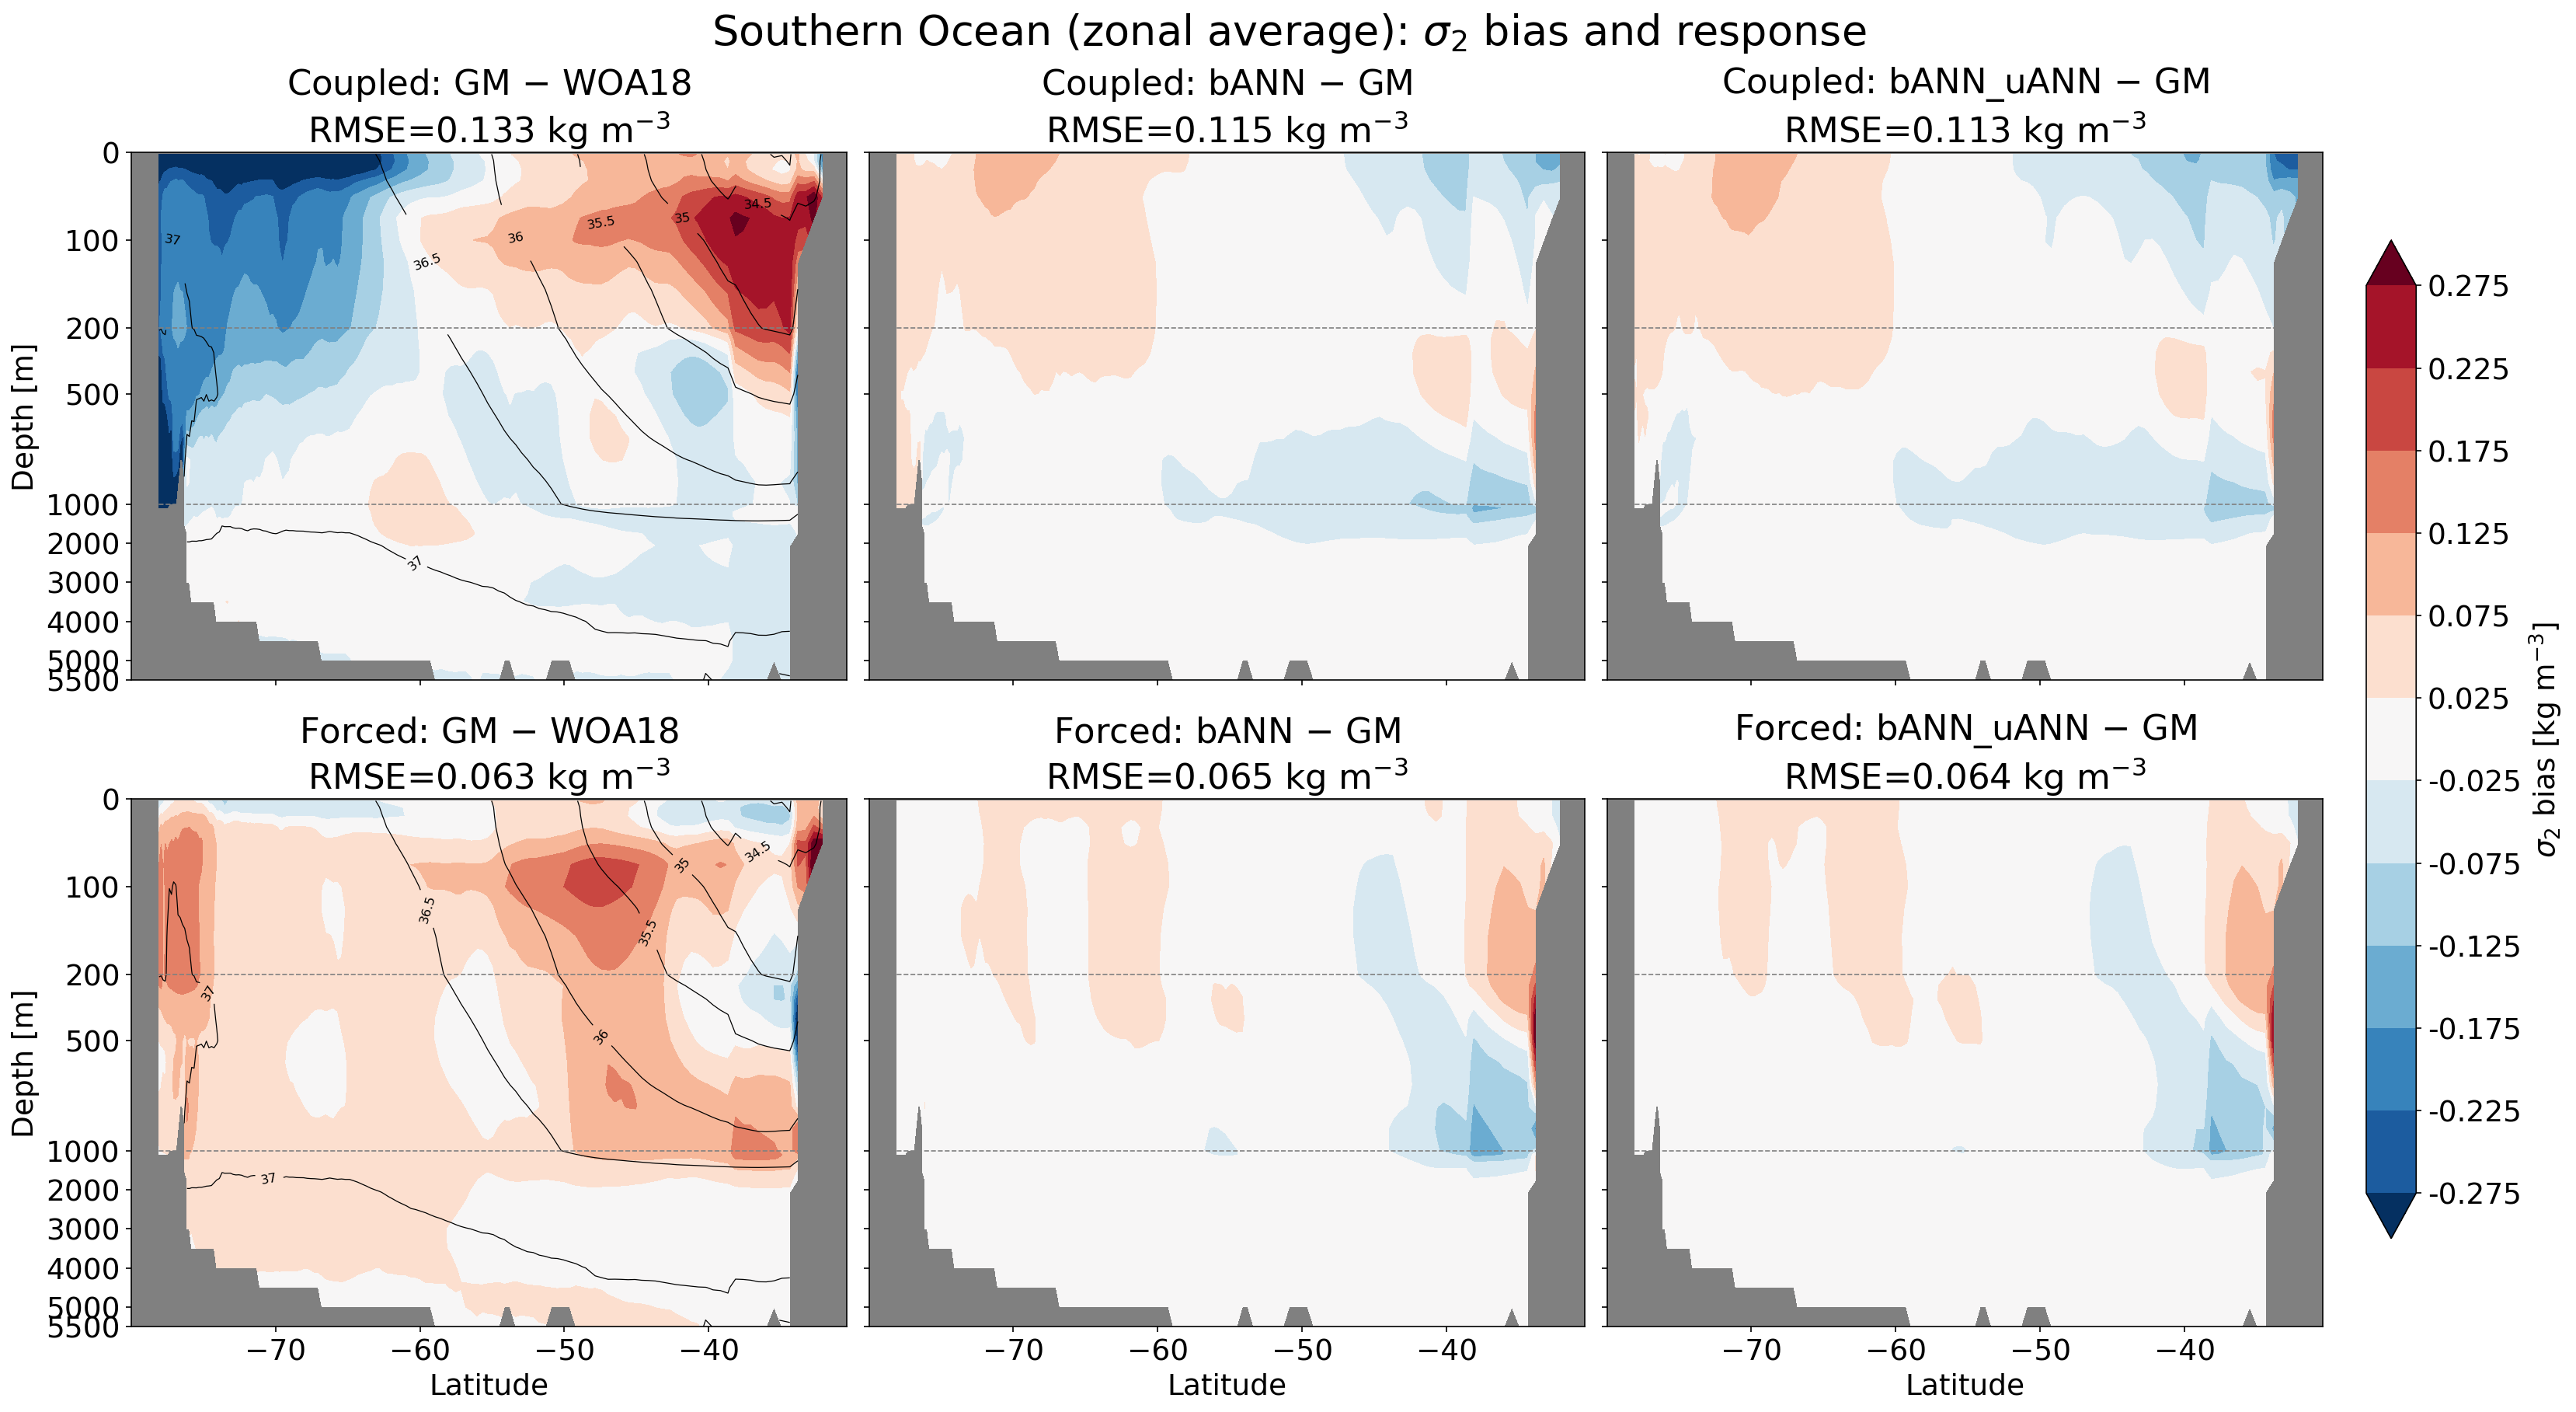

In [15]:
# Southern Ocean: zonal average over the Southern Ocean basin mask, 80S-30S
plot_sigma2_region(lambda f, e: so_zonal(f, e, -80.0, -30.0),
                   r'Southern Ocean (zonal average): $\sigma_2$ bias and response')

## North Atlantic (zonal average)

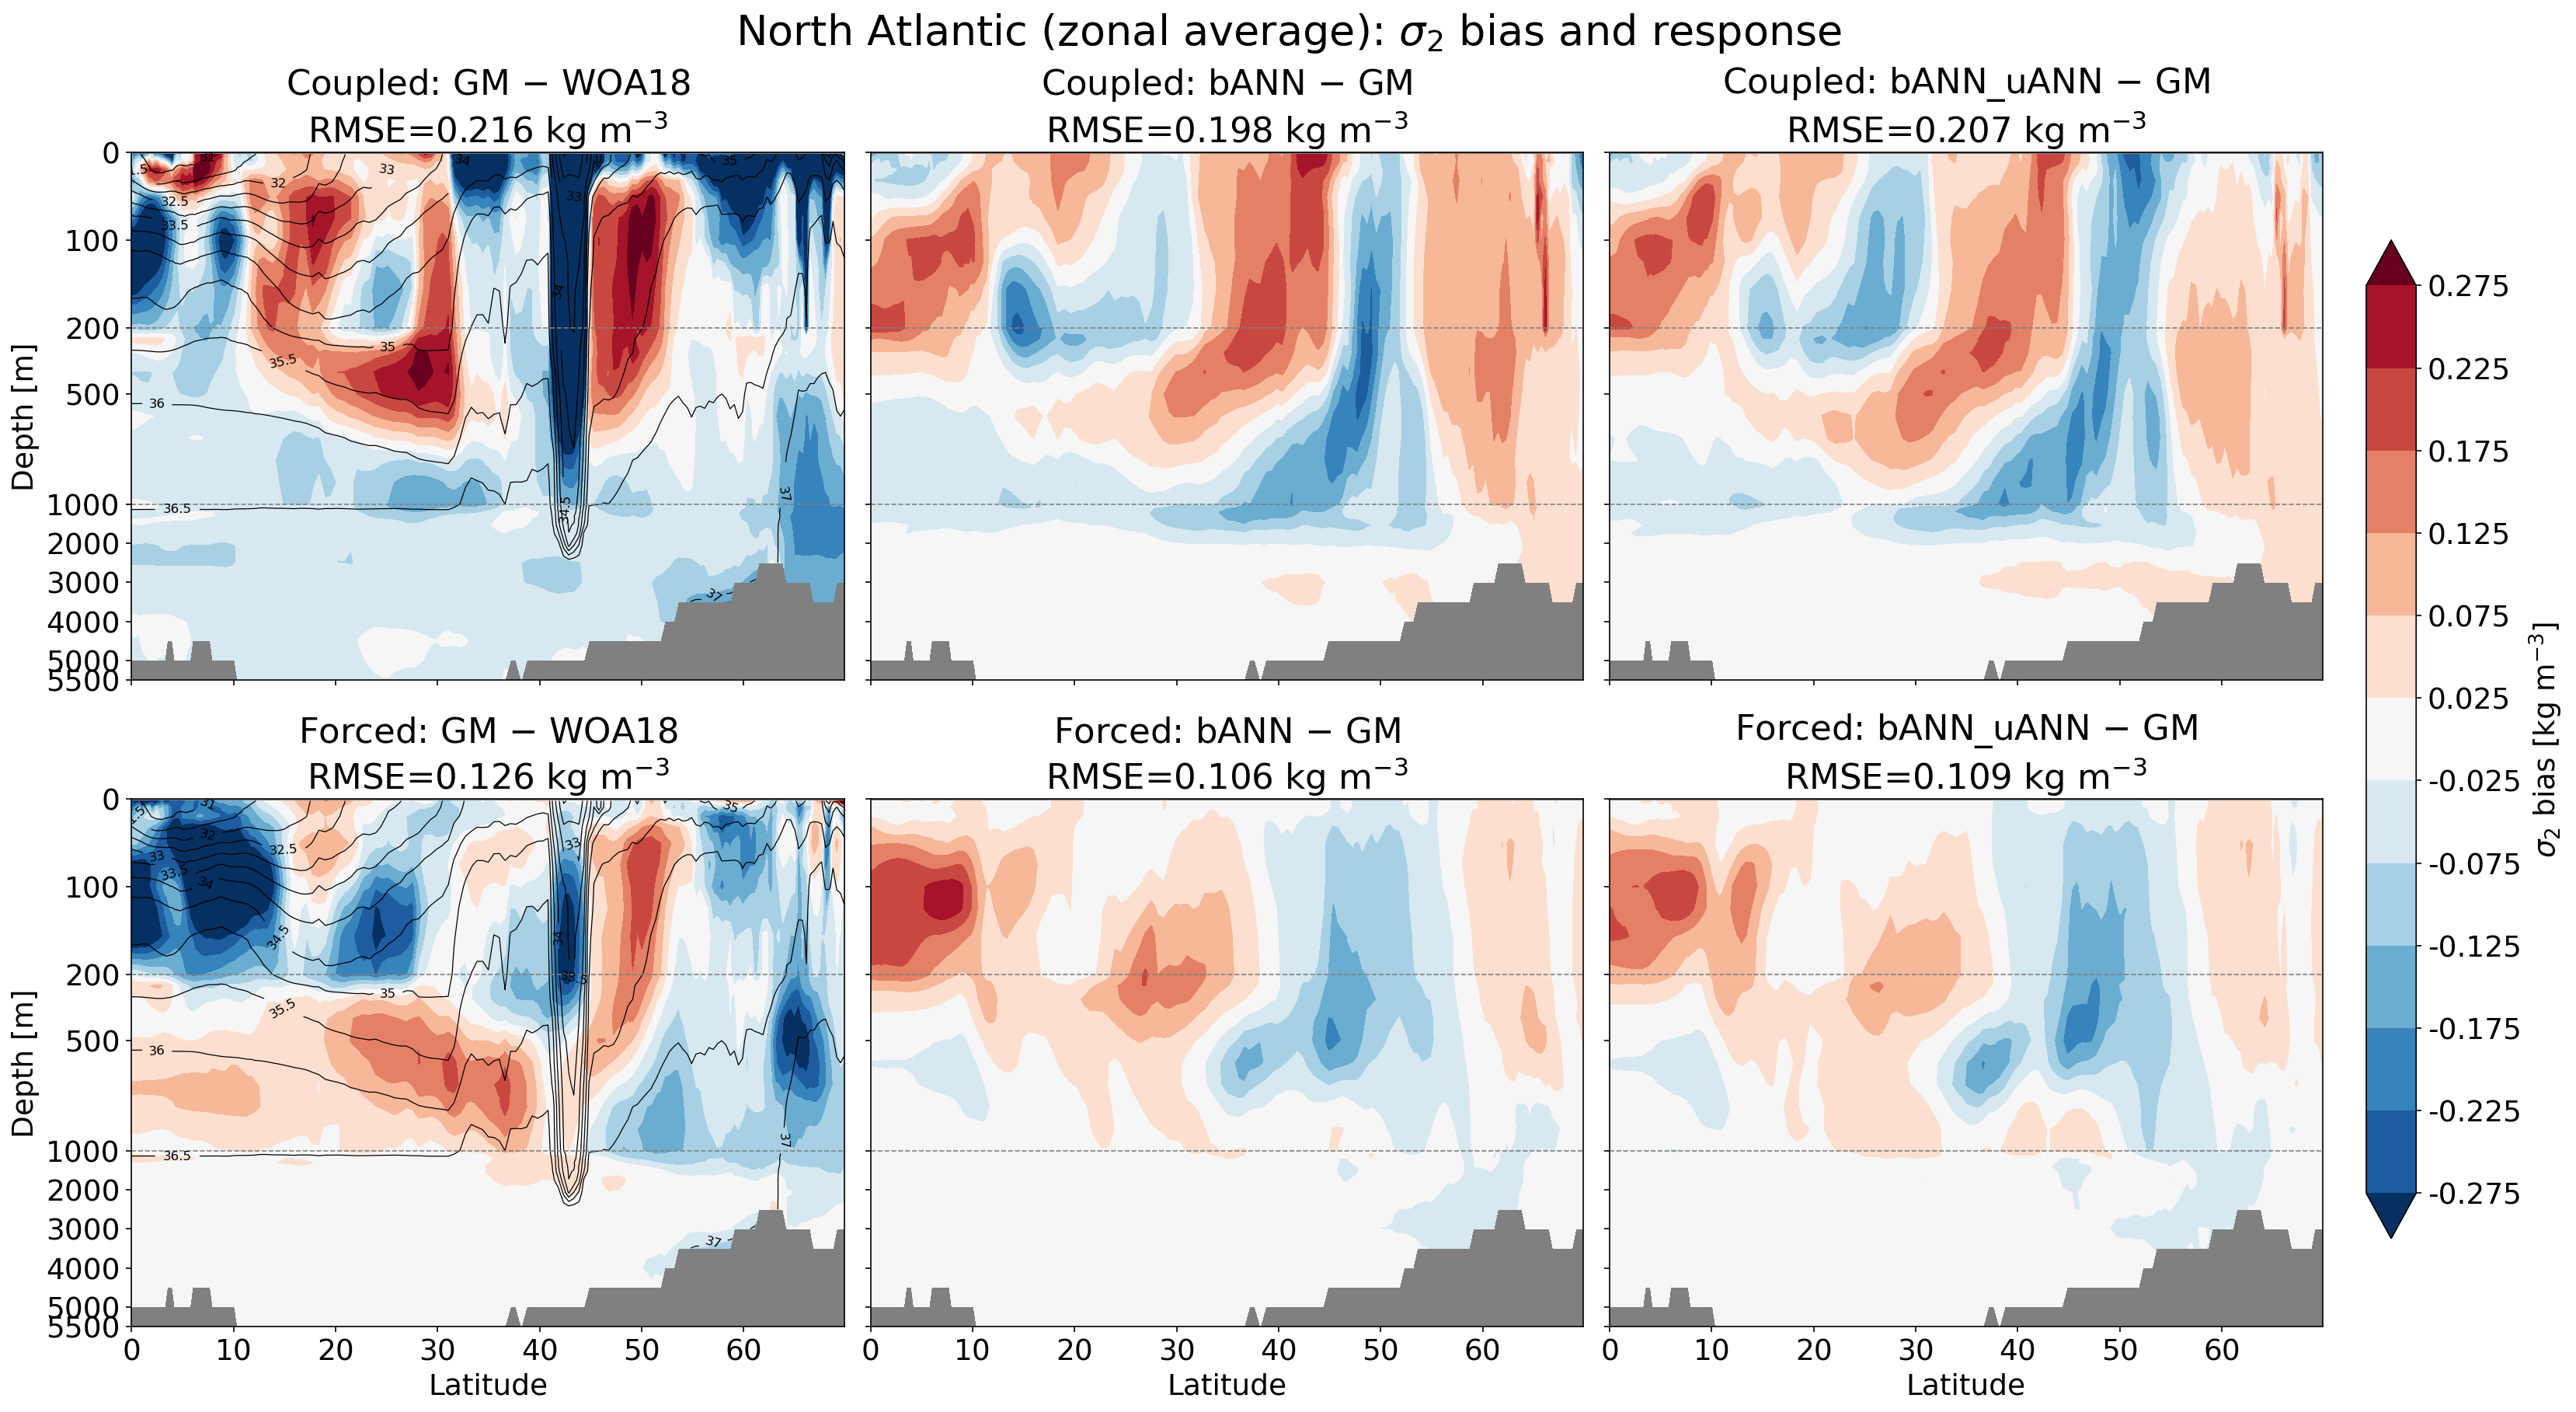

In [8]:
# North Atlantic: zonal average over the Atlantic basin mask, 0-70N
plot_sigma2_region(lambda f, e: atl_zonal(f, e, 0.0, 70.0),
                   r'North Atlantic (zonal average): $\sigma_2$ bias and response')

## Pacific Ocean (zonal average)

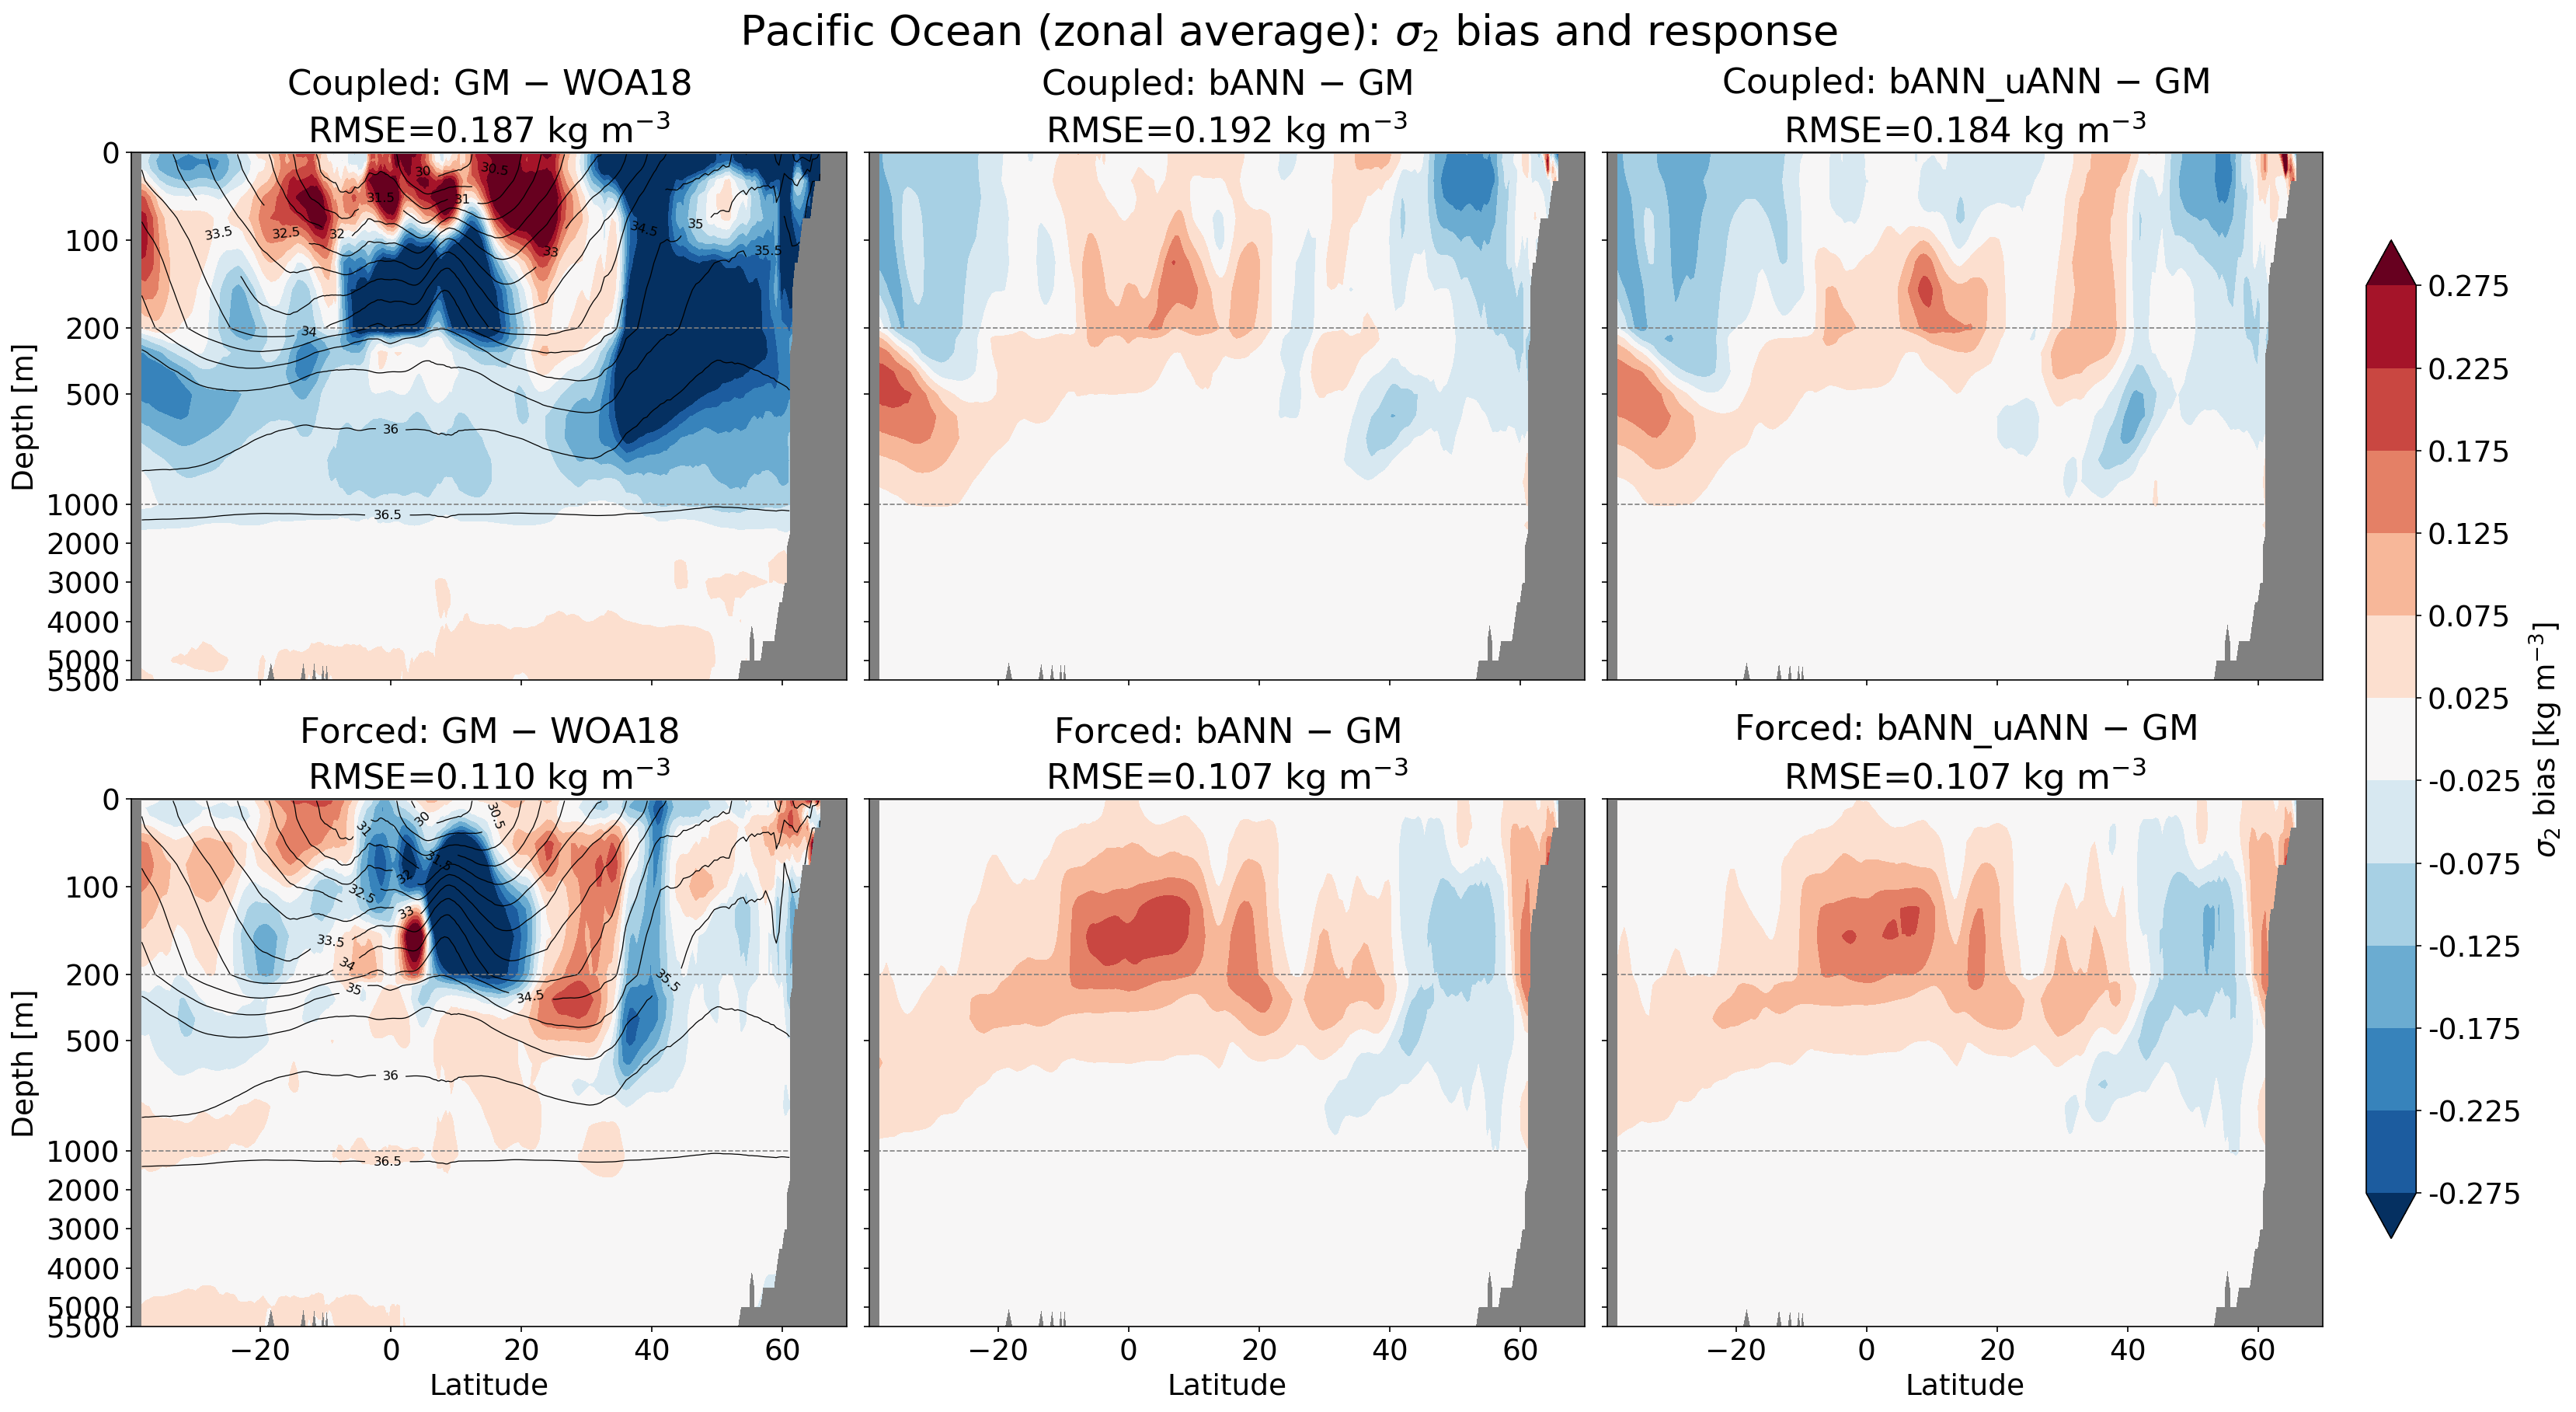

In [9]:
# Pacific Ocean: zonal average over the Pacific basin mask
plot_sigma2_region(lambda f, e: pac_zonal(f, e),
                   r'Pacific Ocean (zonal average): $\sigma_2$ bias and response')

## Indian Ocean (zonal average)

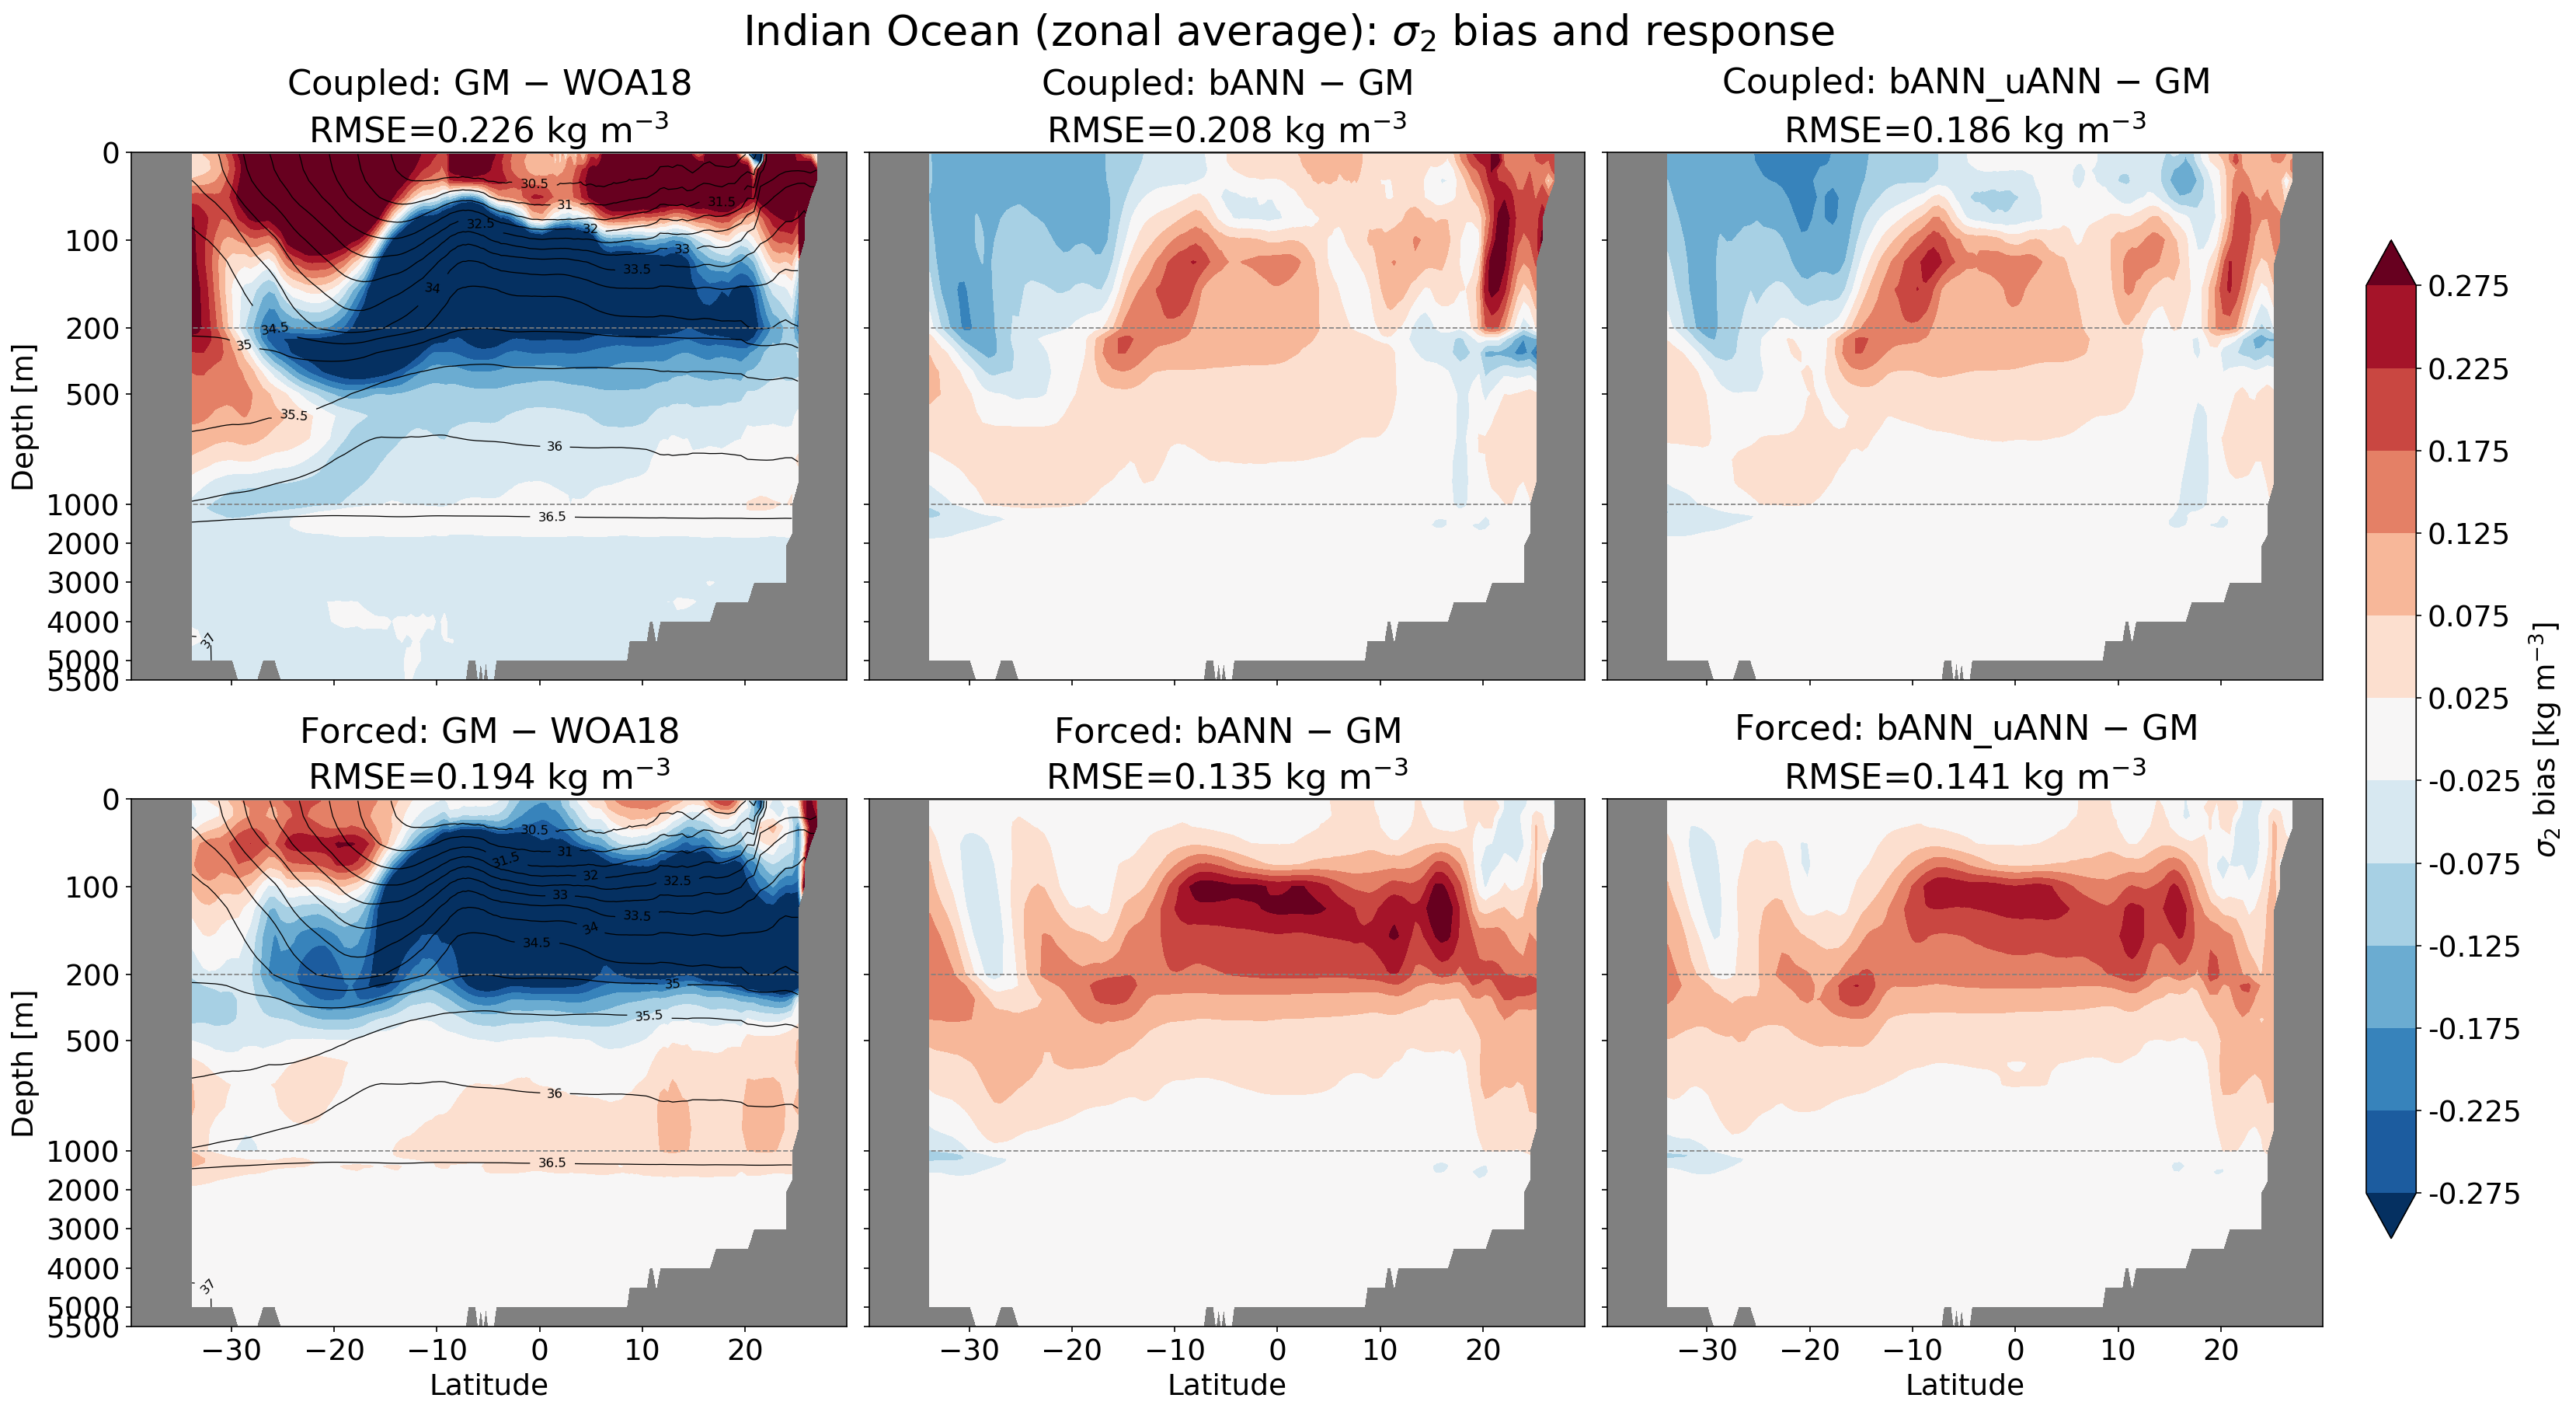

In [10]:
# Indian Ocean: zonal average over the Indian basin mask
plot_sigma2_region(lambda f, e: ind_zonal(f, e),
                   r'Indian Ocean (zonal average): $\sigma_2$ bias and response')